mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.746699999988079 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.2.25                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.11                          pyhd8ed1ab_0                  conda-forge                   
+ joblib                        1.5.3 

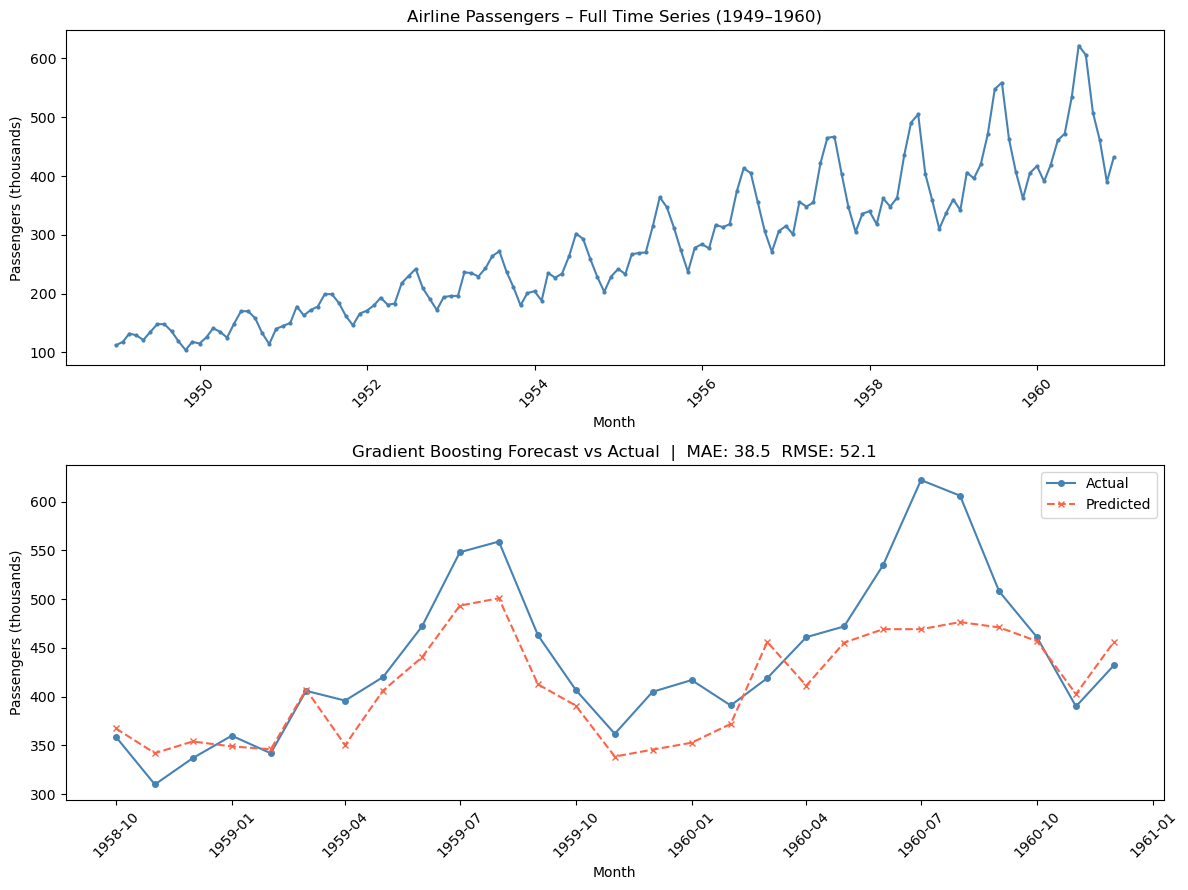

Done.


In [1]:
%matplotlib inline
!mamba install pandas scikit-learn numpy 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('exp7_airlinepassenger.csv')
df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values('Month').reset_index(drop=True)

values = df['Passengers'].values.astype(float)
dates = df['Month']

scaler = MinMaxScaler()
scaled = scaler.fit_transform(values.reshape(-1, 1)).flatten()

SEQ_LEN = 12
X, y = [], []
for i in range(SEQ_LEN, len(scaled)):
    X.append(scaled[i-SEQ_LEN:i])
    y.append(scaled[i])
X, y = np.array(X), np.array(y)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
model.fit(X_train, y_train)

preds = model.predict(X_test)
preds_inv = scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae = mean_absolute_error(y_test_inv, preds_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, preds_inv))
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

test_dates = dates[SEQ_LEN + split:SEQ_LEN + split + len(y_test_inv)]

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

axes[0].plot(dates, values, color='steelblue', linewidth=1.5, marker='o', markersize=2)
axes[0].set_title('Airline Passengers – Full Time Series (1949–1960)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Passengers (thousands)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(test_dates.values, y_test_inv, label='Actual', color='steelblue', marker='o', markersize=4)
axes[1].plot(test_dates.values, preds_inv, label='Predicted', color='tomato', linestyle='--', marker='x', markersize=4)
axes[1].set_title(f'Gradient Boosting Forecast vs Actual  |  MAE: {mae:.1f}  RMSE: {rmse:.1f}')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Passengers (thousands)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('expt7_airline_forecast.png', dpi=150)
plt.show()
print("Done.")